<a href="https://colab.research.google.com/github/sleepymor/ITK-IF2514403-machine-learning-final/blob/main/ML_A_BreastCancer_K2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Preliminary Result Kelompok 5 - Prediksi Risiko Kanker Payudara

### Import Library

Berikut adalah list dari library yang kami gunakan beserta alasannya


1.   Pandas

      Digunakan untuk melakukan manajemen data dengan kemampuannya memanipulasi data tabular secara fleksibel. Sangat Krusial dalam tahap melakukan *Data Cleaning*, seperti menghapus baris yang kosong, mengubah tipe data, serta melakukan seleksi fitur-fitur dari dataset mentah.

2.   Numpy

      Digunakan untuk melakukan komputasi numerik melalui Struktur *N-dimensional Array*, delain itu juga digunakan karena efisiensi memori dan juga kecepatan eksekusi yang melampaui list standar python.

3.   SKLearn

      *Scikit-Learn* (SKLearn) digunakan sebagai jalur antara data yang sudah bersih dan model ML. Dalam tahap *perliminary*, *library* ini digunakan untuk prapemrosesan teknis seperti *scaling* (menyamakan skala angka), *encoding* (mengubah teks menjadi angka), serta membagi data menjadi bagian *training* dan *testing*.

4.   Matplotlib & Seaborn

      *Library* yang digunakan untuk memvisualisasikan data dan hasil analisis




In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

Section ini menangani proses pemuatan dan inspeksi awal terhadap data mentah.

1.  Dataset dimuat menggunakan perintah `pd.read_csv('data.csv')`.

2.  Dilakukan pengecekan missing values (nilai kosong).

3.  Pengecekan data duplikat menunjukkan tidak ada baris ganda (0 duplikat) dalam dataset.

In [3]:
df = pd.read_csv('breast_cancer_raw.csv')

In [4]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [6]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [7]:
missing_values = df.isnull().sum()
print(missing_values)

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [8]:
nan_values = df.isna().sum()
print(nan_values)

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [9]:
duplicate_values = df.duplicated().sum()
print(duplicate_values)

0


### Explanatory Data Analysis (EDA)

Tahap eksplorasi ini bertujuan memahami distribusi data dan hubungan antar fitur sebelum masuk ke pemodelan.

Distribusi Fitur Utama: 
Dilakukan analisis kepadatan (Density Plot) dan analisis Boxplot yang dikelompokkan berdasarkan diagnosis untuk fitur-fitur penting seperti Radius Mean, Texture Mean, dan Concavity Mean.

Analisis Korelasi: Menghasilkan Correlation Matrix (Heatmap) untuk melihat korelasi antar fitur. Ditemukan 10 fitur teratas yang sangat berkorelasi dengan kanker ganas.

Perbandingan Mean vs Worst: Dilakukan komparasi distribusi antara radius_mean dan radius_worst untuk setiap kelas diagnosis menggunakan KDE plot


#### Distribusi target variable 'diagnosis'

In [10]:
target_dist = df['diagnosis'].value_counts()
print("Distribusi Diagnosis:")
print(target_dist)
print(f"\nPersentase:")
print(target_dist / len(df) * 100)

Distribusi Diagnosis:
diagnosis
B    357
M    212
Name: count, dtype: int64

Persentase:
diagnosis
B    62.741652
M    37.258348
Name: count, dtype: float64


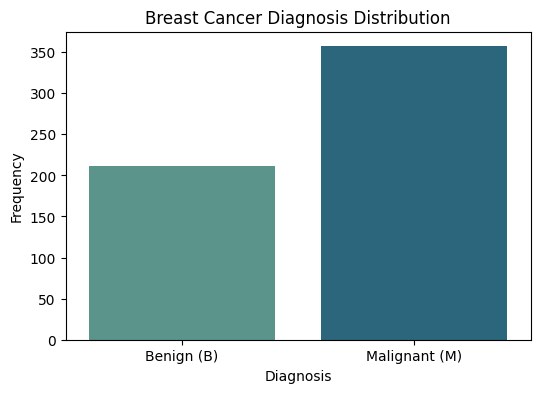

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='diagnosis', hue='diagnosis', palette='crest', legend=False)

plt.xticks(ticks=[0, 1], labels=['Benign (B)', 'Malignant (M)'])
plt.title('Breast Cancer Diagnosis Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Frequency')
plt.show()

#### Distribusi Fitur Utama

##### 1. Radius Mean

In [12]:

print("Statistik Radius Mean:")
print(df.groupby('diagnosis')['radius_mean'].describe())


Statistik Radius Mean:
           count       mean       std     min     25%     50%    75%    max
diagnosis                                                                  
B          357.0  12.146524  1.780512   6.981  11.080  12.200  13.37  17.85
M          212.0  17.462830  3.203971  10.950  15.075  17.325  19.59  28.11


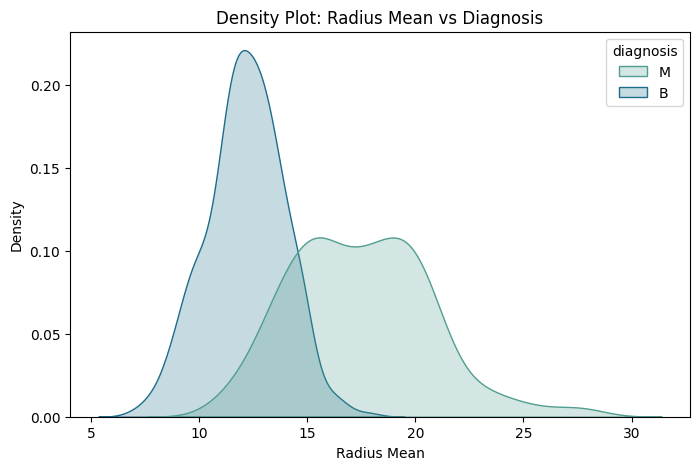

In [13]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='radius_mean', hue='diagnosis', fill=True, common_norm=False, palette='crest')
plt.title('Density Plot: Radius Mean vs Diagnosis')
plt.xlabel('Radius Mean')
plt.ylabel('Density')
plt.show()

##### 2. Texture Mean

In [14]:
print("Statistik Texture Mean:")
print(df.groupby('diagnosis')['texture_mean'].describe())

Statistik Texture Mean:
           count       mean       std    min      25%    50%     75%    max
diagnosis                                                                  
B          357.0  17.914762  3.995125   9.71  15.1500  17.39  19.760  33.81
M          212.0  21.604906  3.779470  10.38  19.3275  21.46  23.765  39.28


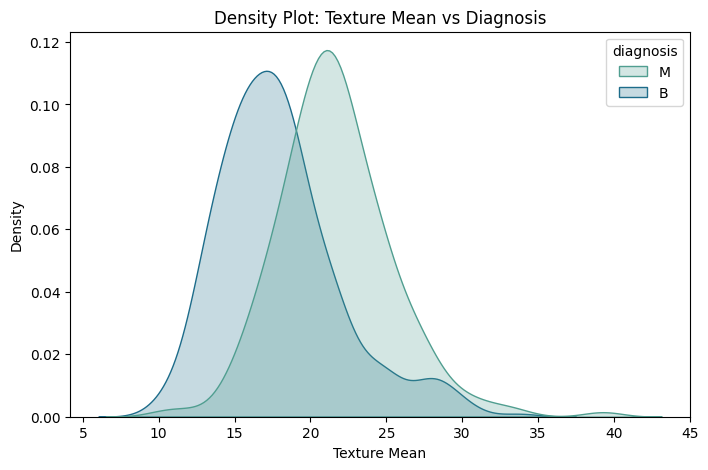

In [15]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='texture_mean', hue='diagnosis', fill=True, common_norm=False, palette='crest')
plt.title('Density Plot: Texture Mean vs Diagnosis')
plt.xlabel('Texture Mean')
plt.ylabel('Density')
plt.show()

##### 3. Concavity Mean

In [16]:
print("Statistik Concavity Mean:")
print(df.groupby('diagnosis')['concavity_mean'].describe())

Statistik Concavity Mean:
           count      mean       std      min       25%      50%      75%  \
diagnosis                                                                   
B          357.0  0.046058  0.043442  0.00000  0.020310  0.03709  0.05999   
M          212.0  0.160775  0.075019  0.02398  0.109525  0.15135  0.20305   

              max  
diagnosis          
B          0.4108  
M          0.4268  


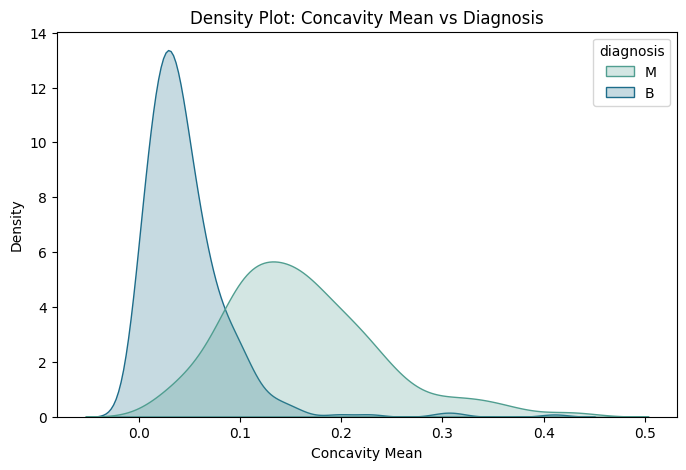

In [17]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='concavity_mean', hue='diagnosis', fill=True, common_norm=False, palette='crest')
plt.title('Density Plot: Concavity Mean vs Diagnosis')
plt.xlabel('Concavity Mean')
plt.ylabel('Density')
plt.show()

#### Boxplot Analysis

In [18]:
key_features = ['radius_mean','texture_mean','perimeter_mean','area_mean','concavity_mean']
print("Statistik Fitur Utama:")
print(df.groupby('diagnosis')[key_features].median())

Statistik Fitur Utama:
           radius_mean  texture_mean  perimeter_mean  area_mean  \
diagnosis                                                         
B               12.200         17.39           78.18      458.4   
M               17.325         21.46          114.20      932.0   

           concavity_mean  
diagnosis                  
B                 0.03709  
M                 0.15135  


/tmp/ipykernel_45955/715214382.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=feature, ax=axes[idx], palette='crest')
/tmp/ipykernel_45955/715214382.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=feature, ax=axes[idx], palette='crest')
/tmp/ipykernel_45955/715214382.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=feature, ax=axes[idx], palette='crest')
/tmp/ipykernel_45955/715214382.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is d

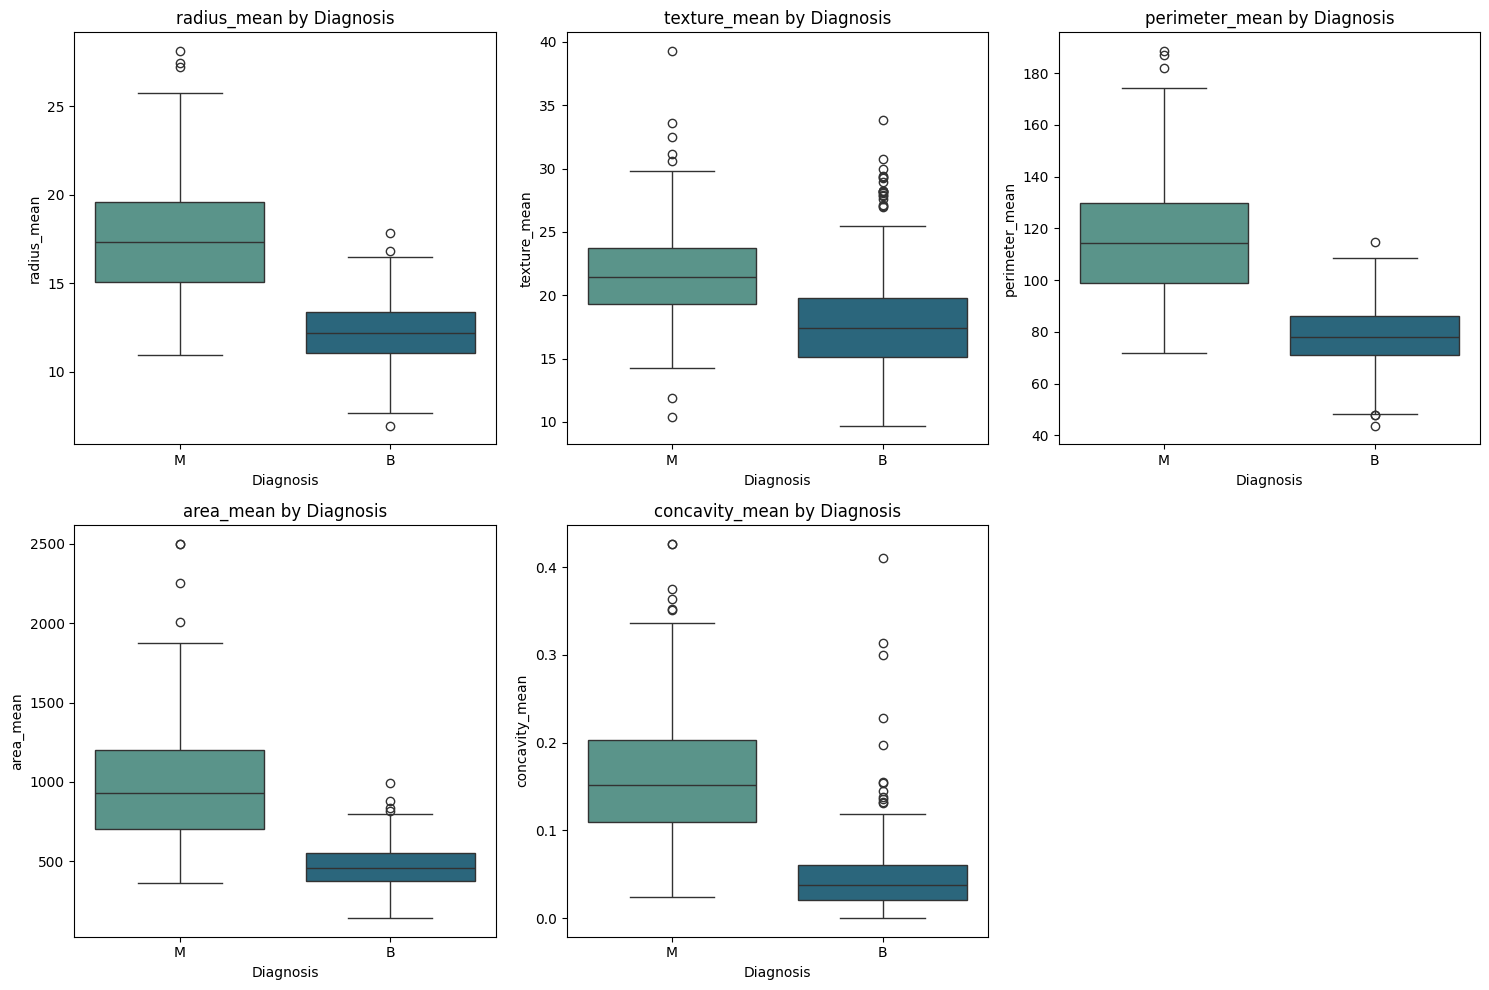

In [19]:
fig, axes = plt.subplots(2,3, figsize=(15,10))
axes = axes.flatten()

for idx, feature in enumerate(key_features):
    sns.boxplot(data=df, x='diagnosis', y=feature, ax=axes[idx], palette='crest')
    axes[idx].set_title(f'{feature} by Diagnosis')
    axes[idx].set_xlabel('Diagnosis')
    axes[idx].set_ylabel(feature)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

#### Correlation Analysis

In [20]:
numerical_features = df.drop(columns=['diagnosis']).columns
corr_matrix = df[numerical_features].corr()

print("Top 10 Features Most Correlated with Malignancy:")
target_corr = df[numerical_features].corrwith(df['diagnosis'].map({'M':1,'B':0})).abs().sort_values(ascending=False)
print(target_corr.head(10))

Top 10 Features Most Correlated with Malignancy:
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
dtype: float64


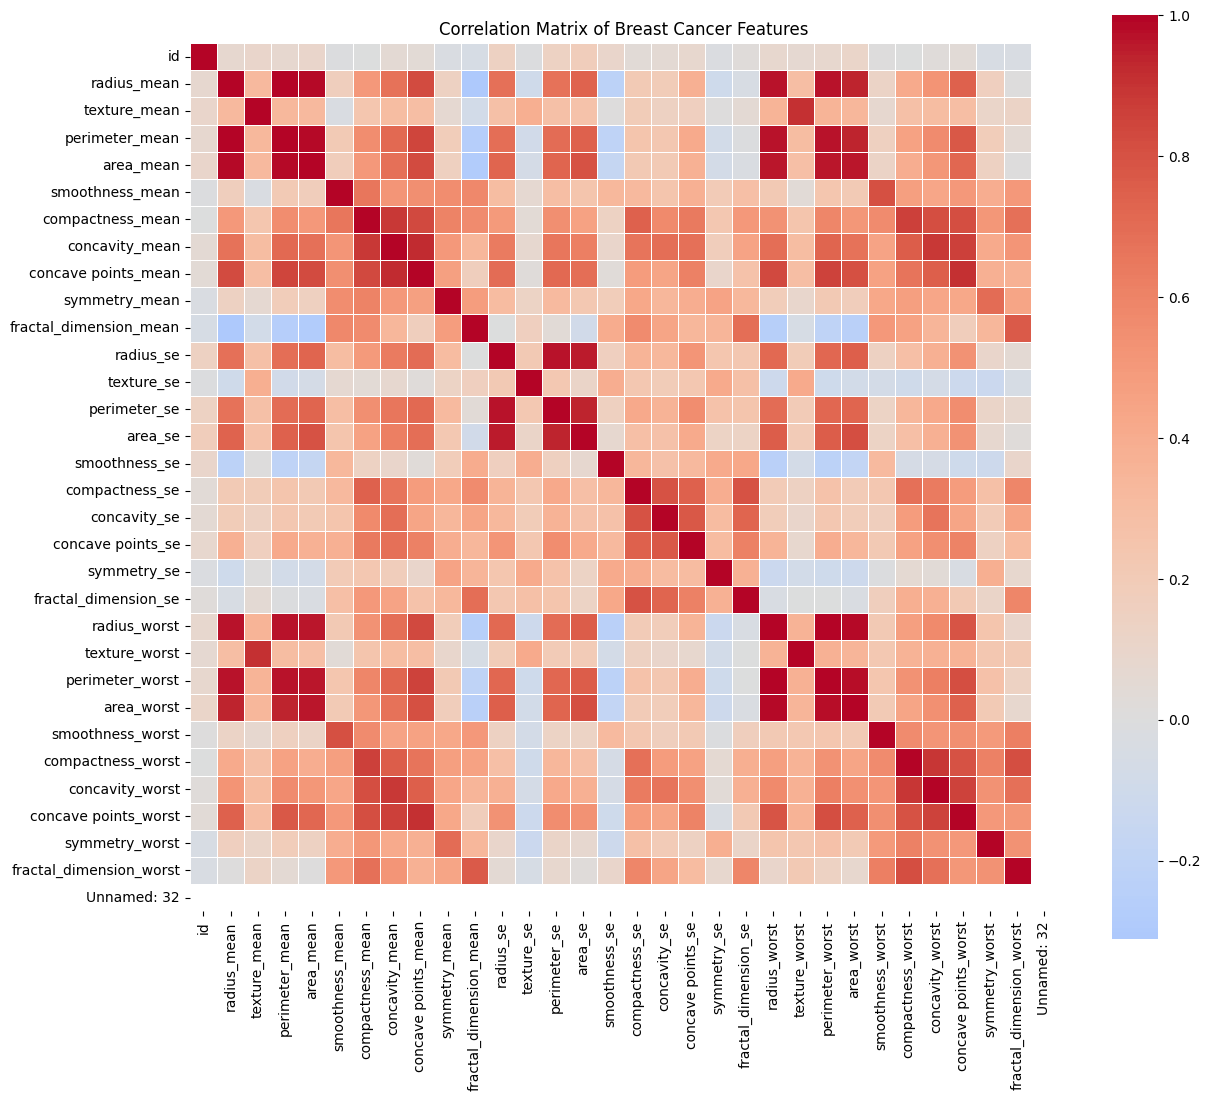

In [21]:
plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix of Breast Cancer Features')
plt.show()

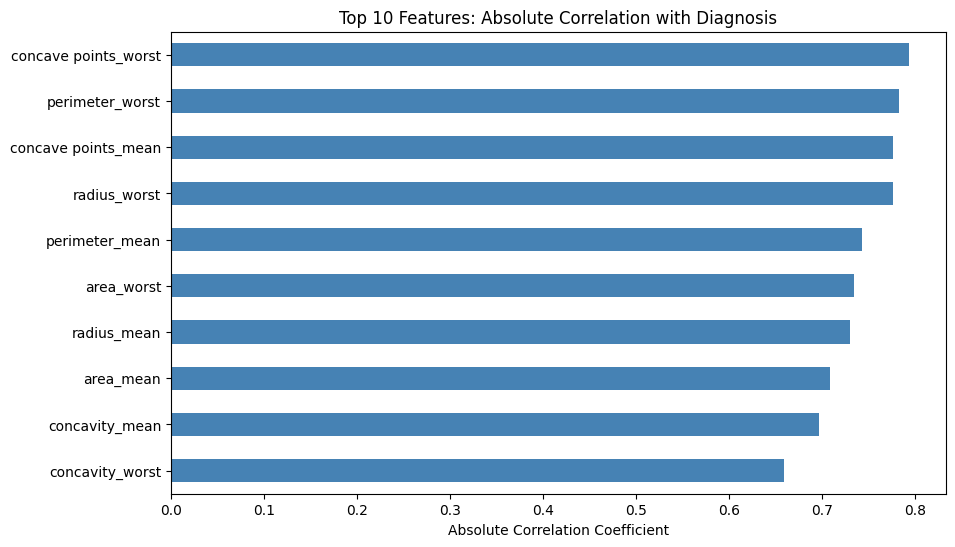

In [22]:
plt.figure(figsize=(10,6))
target_corr.head(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 Features: Absolute Correlation with Diagnosis')
plt.xlabel('Absolute Correlation Coefficient')
plt.gca().invert_yaxis()
plt.show()

#### Pairplot Analysis

In [23]:
sample_features = ['radius_mean','texture_mean','concavity_mean']
print("Statistik Pairplot Features:")
print(df[sample_features].describe())

Statistik Pairplot Features:
       radius_mean  texture_mean  concavity_mean
count   569.000000    569.000000      569.000000
mean     14.127292     19.289649        0.088799
std       3.524049      4.301036        0.079720
min       6.981000      9.710000        0.000000
25%      11.700000     16.170000        0.029560
50%      13.370000     18.840000        0.061540
75%      15.780000     21.800000        0.130700
max      28.110000     39.280000        0.426800


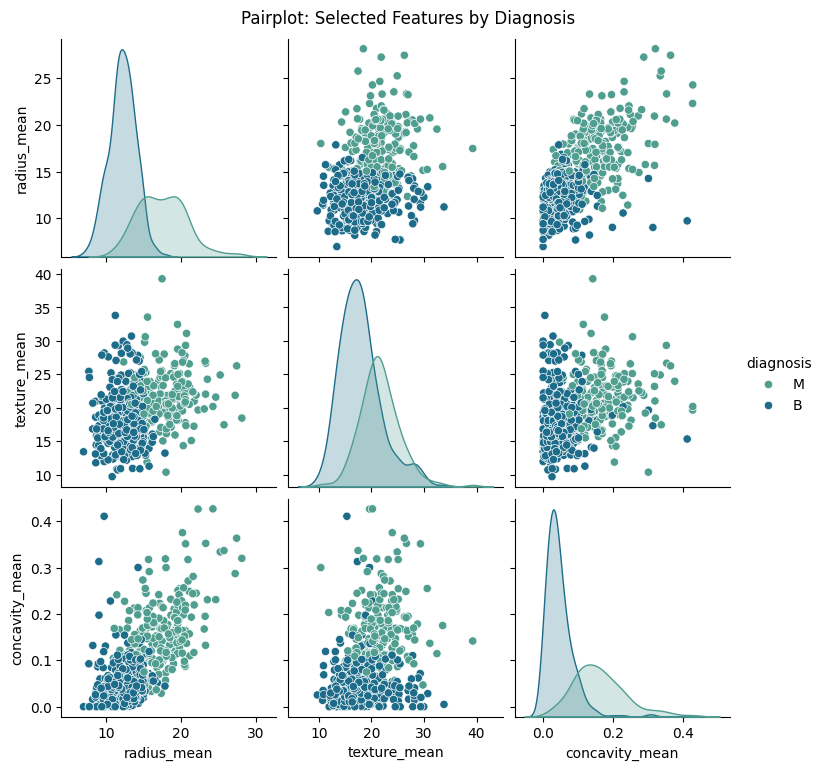

In [24]:
sns.pairplot(df[['radius_mean','texture_mean','concavity_mean','diagnosis']], hue='diagnosis', palette='crest', diag_kind='kde')
plt.suptitle('Pairplot: Selected Features by Diagnosis', y=1.02)
plt.show()

#### Mean vs Worst Comparison

In [25]:
print("Perbandingan Radius Mean vs Radius Worst:")
print(df.groupby('diagnosis')[['radius_mean','radius_worst']].median())

Perbandingan Radius Mean vs Radius Worst:
           radius_mean  radius_worst
diagnosis                           
B               12.200         13.35
M               17.325         20.59


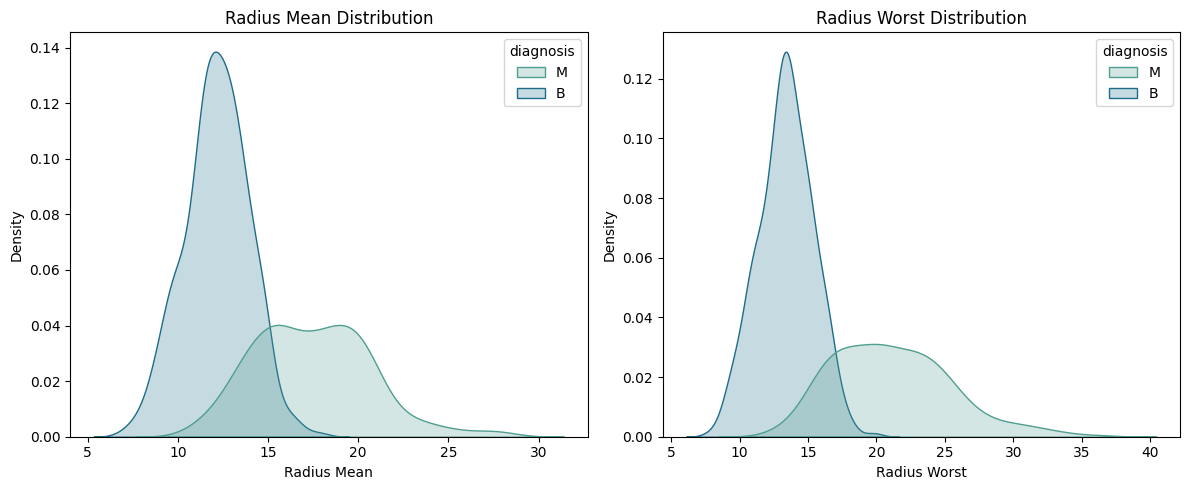

In [26]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.kdeplot(data=df, x='radius_mean', hue='diagnosis', fill=True, ax=axes[0], palette='crest')
axes[0].set_title('Radius Mean Distribution')
axes[0].set_xlabel('Radius Mean')

sns.kdeplot(data=df, x='radius_worst', hue='diagnosis', fill=True, ax=axes[1], palette='crest')
axes[1].set_title('Radius Worst Distribution')
axes[1].set_xlabel('Radius Worst')

plt.tight_layout()
plt.show()

In [27]:
raise SystemExit

SystemExit: 

/home/giant/Desktop/project/ITK-IF2514403-machine-learning-final/.venv/lib64/python3.14/site-packages/IPython/core/interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


### Data Cleaning

Section ini melakukan pembersihan dan penyeragaman tipe label data pada variabel target.

Fitur target diagnosis dikonversi dari format teks ke format numerik statis. Label 'M' (Malignant) diubah menjadi angka 1, dan 'B' (Benign) diubah menjadi angka 0.

Tipe data kolom diagnosis telah berhasil diubah menjadi tipe int64.


In [28]:
# Konversi diagnosis ke numerik (M=1, B=0)
df_clean = df.copy()
df_clean['diagnosis'] = df_clean['diagnosis'].map({'M':1, 'B':0})
df_clean = df_clean.drop(columns=['Unnamed: 32', 'id'])

print("Tipe data diagnosis setelah konversi:")
print(df_clean.dtypes['diagnosis'])

print("\nDistribusi diagnosis setelah konversi:")
print(df_clean['diagnosis'].value_counts())



Tipe data diagnosis setelah konversi:
int64

Distribusi diagnosis setelah konversi:
diagnosis
0    357
1    212
Name: count, dtype: int64


In [29]:
df_clean.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Feature Engineering

Tahapan ini memisahkan fitur dengan target serta memproduksi variabel-variabel baru yang dapat meningkatkan performa model.
Dataset dipisahkan menjadi matriks fitur X (berukuran 569 x 32) dan target y.

Fitur baru yang ditambahkan mencakup:
area_perimeter_ratio: Rasio antara area_mean dan perimeter_mean sebagai indikasi bentuk (compactness).

radius_growth_ratio: Rasio antara radius_worst terhadap radius_mean untuk mendeteksi pertumbuhan abnormal.

concavity_score: Skor gabungan yang ditambahkan dari concavity_mean dan concave points_mean.


In [30]:
X = df_clean.drop(columns='diagnosis')
y = df_clean['diagnosis']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (569, 30)
Target shape: (569,)


In [31]:
df_clean

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [32]:
# Rasio area terhadap perimeter (indikasi bentuk / compactness)
X['area_perimeter_ratio'] = X['area_mean'] / X['perimeter_mean']

# Rasio radius worst terhadap radius mean (indikasi pertumbuhan abnormal)
X['radius_growth_ratio'] = X['radius_worst'] / X['radius_mean']

# Total skor "concavity" (gabungan concavity_mean + concave points_mean)
X['concavity_score'] = X['concavity_mean'] + X['concave points_mean']

print("Fitur baru ditambahkan:")
print(['area_perimeter_ratio','radius_growth_ratio','concavity_score'])


Fitur baru ditambahkan:
['area_perimeter_ratio', 'radius_growth_ratio', 'concavity_score']


### Feature Encoding

Section ini mengubah variabel berskala non-numerik atau kategorikal di dalam matriks fitur menjadi bentuk yang bisa diproses oleh algoritma numerik.

Ordinal Encoding: Dilakukan kategorisasi dari radius_mean menjadi kolom baru RadiusCategory yang terbagi atas Small (<12), Medium (12 - <18), dan Large (>=18)
. Kolom teks tersebut kemudian di-map ke bentuk numerik berturut-turut menjadi 0, 1, dan 2.

Categorical Encoding (One-Hot Encoding): Diterapkan menggunakan metode pd.get_dummies pada variabel kategorikal (seperti RadiusCategory), baik dengan pengaturan drop_first=True maupun drop_first=False untuk menghindari masalah multikolinearitas dan memperluas dimensi kolom fitur (menghasilkan hingga 39 kolom).

#### Ordinal Encoding

In [33]:
# Membuat kategori ordinal berdasarkan radius_mean
def categorize_radius(value):
    if value < 12:
        return "Small"
    elif 12 <= value < 18:
        return "Medium"
    else:
        return "Large"

X['RadiusCategory'] = X['radius_mean'].apply(categorize_radius)

print("Contoh hasil kategorisasi radius_mean:")
print(X[['radius_mean','RadiusCategory']].head())

Contoh hasil kategorisasi radius_mean:
   radius_mean RadiusCategory
0        17.99         Medium
1        20.57          Large
2        19.69          Large
3        11.42          Small
4        20.29          Large


In [34]:
# Mapping kategori ke nilai numerik (ordinal encoding)
radius_map = {
    "Small": 0,
    "Medium": 1,
    "Large": 2
}

X['RadiusCategory'] = X['RadiusCategory'].map(radius_map)

print("\nDistribusi kategori setelah encoding:")
print(X['RadiusCategory'].value_counts())


Distribusi kategori setelah encoding:
RadiusCategory
1    308
0    169
2     92
Name: count, dtype: int64


In [35]:
X

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,area_perimeter_ratio,radius_growth_ratio,concavity_score,RadiusCategory
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,8.151466,1.410784,0.44720,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,9.977427,1.214876,0.15707,2
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,9.253846,1.197054,0.32530,2
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,4.976798,1.305604,0.34660,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,9.600296,1.110892,0.30230,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,10.415493,1.180427,0.38280,2
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,9.611280,1.176850,0.24191,2
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,7.923361,1.143373,0.14553,1
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,9.029265,1.249515,0.50340,2


#### Categorical Encoding

In [36]:
# Identifikasi kolom kategorikal (tipe object)
cat_features = X.select_dtypes(include=['object']).columns

print("Fitur kategorikal terdeteksi:")
print(cat_features if len(cat_features) > 0 else "Tidak ada fitur kategorikal asli, hanya fitur turunan seperti RadiusCategory")

Fitur kategorikal terdeteksi:
Tidak ada fitur kategorikal asli, hanya fitur turunan seperti RadiusCategory


In [37]:
# Lakukan One-Hot Encoding pada fitur kategorikal
# X_enc = pd.get_dummies(X, columns=cat_features, drop_first=True, dtype=int)

# print("\nContoh hasil encoding (5 baris pertama):")
# X_enc.head()

In [38]:
# X_en

#### Categorical Encoding without drop first

In [39]:
# Lakukan One-Hot Encoding pada fitur kategorikal tanpa drop_first
# X_enc = pd.get_dummies(X, columns=cat_features, drop_first=False, dtype=int)

# print("\nContoh hasil encoding (5 baris pertama):")
# print(X_enc.head())


In [40]:
# X_enc.info()

### Feature Scaling

Section pemrosesan tahap akhir yang menyeimbangkan skala pada tiap-tiap nilai kolom sehingga tidak ada fitur yang secara artifisial mendominasi karena satuan ukur yang besar.

StandardScaler: Diterapkan pada keseluruhan set data yang telah di-encode agar tiap kolom memiliki nilai mean yang dinormalisasi, menghasilkan matriks data berskala standar yang siap digunakan untuk pemodelan.

MinMaxScaler: Diimplementasikan khusus untuk mengonversi nilai menjadi rasio skala 0 hingga 1 pada kelompok fitur terpilih seperti radius_mean, texture_mean, perimeter_mean, area_mean, dan concavity_mean
.

#### StandartScaler

In [41]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [42]:
X_final = pd.DataFrame(X_scaled, columns=X.columns)
print("Data preprocessing completed successfully. Matrix is ready for modeling.")

Data preprocessing completed successfully. Matrix is ready for modeling.


In [43]:
X_final

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,area_perimeter_ratio,radius_growth_ratio,concavity_score,RadiusCategory
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015,0.894884,3.310149,2.659906,0.203921
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190,2.018656,0.897126,0.166321,1.710816
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391,1.573335,0.677613,1.612210,1.710816
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010,-1.058938,2.014637,1.795277,-1.302974
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100,1.786555,-0.383659,1.414531,1.710816
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,2.110995,0.721473,2.060786,2.343856,1.041842,0.219060,1.947285,2.320965,-0.312589,-0.931027,...,0.378365,-0.273318,0.664512,1.629151,-1.360158,-0.709091,2.288261,0.472809,2.106406,1.710816
565,1.704854,2.085134,1.615931,1.723842,0.102458,-0.017833,0.693043,1.263669,-0.217664,-1.058611,...,-0.691230,-0.394820,0.236573,0.733827,-0.531855,-0.973978,1.793315,0.428760,0.895497,1.710816
566,0.702284,2.045574,0.672676,0.577953,-0.840484,-0.038680,0.046588,0.105777,-0.809117,-0.895587,...,-0.809587,0.350735,0.326767,0.414069,-1.104549,-0.318409,0.754499,0.016419,0.067138,0.203921
567,1.838341,2.336457,1.982524,1.735218,1.525767,3.272144,3.296944,2.658866,2.137194,1.043695,...,1.430427,3.904848,3.197605,2.289985,1.919083,2.219635,1.435118,1.323773,3.142929,1.710816


#### MinMax Scaler

In [44]:
# columns_to_scale = [
#     'radius_mean',
#     'texture_mean',
#     'perimeter_mean',
#     'area_mean',
#     'concavity_mean'
# ]

# print("Kolom yang akan diskalakan:")
# print(columns_to_scale)

In [45]:
# scaler = MinMaxScaler()

# # Terapkan MinMaxScaler pada kolom terpilih
# X_enc[columns_to_scale] = scaler.fit_transform(X_enc[columns_to_scale])

# print("\nContoh hasil scaling (5 baris pertama):")
# print(X_enc[columns_to_scale].head())

In [46]:
# X_enc

In [47]:
y

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64

In [51]:
# X_final.to_csv('breast_cancer_preprocessed.csv', index=False)
data_clean = pd.DataFrame(X_final)
data_clean['diagnosis'] = y.values

data_clean.to_csv('breast_cancer_preprocessed.csv', index=False)

In [ ]:

\

# 2. SPLIT DATASET
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42, stratify=y)

# 3. FUNGSI EVALUASI
def evaluate_model(model_name, y_true, y_pred, y_prob):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc_roc = roc_auc_score(y_true, y_prob)
    return [precision, recall, f1, auc_roc]

results = []

# 4. MODEL BASELINE (Logistic Regression + PCA)
pca = PCA(n_components=10)
logreg = LogisticRegression(random_state=42)
baseline_pipeline = Pipeline([('pca', pca), ('logreg', logreg)])

baseline_pipeline.fit(X_train, y_train)
y_pred_base = baseline_pipeline.predict(X_test)
y_prob_base = baseline_pipeline.predict_proba(X_test)[:, 1]

res_base = evaluate_model("Baseline (LogReg+PCA)", y_test, y_pred_base, y_prob_base)
results.append(['Baseline (LogReg+PCA)'] + res_base)

# 5. MODEL 1 (kNN)
knn = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:, 1]

res_knn = evaluate_model("k-Nearest Neighbors", y_test, y_pred_knn, y_prob_knn)
results.append(['Model 1 (kNN)'] + res_knn)

# 6. MODEL 2 (Random Forest)
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

res_rf = evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)
results.append(['Model 2 (Random Forest)'] + res_rf)

# 7. TAMPILKAN TABEL KOMPARASI
df_results = pd.DataFrame(results, columns=['Algoritma', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'])
print("TABEL KOMPARASI PERFORMA:")
print(df_results.to_markdown(index=False))

TABEL KOMPARASI PERFORMA:
| Algoritma               |   Precision |   Recall |   F1-Score |   AUC-ROC |
|:------------------------|------------:|---------:|-----------:|----------:|
| Baseline (LogReg+PCA)   |           1 | 0.97619  |   0.987952 |  0.999008 |
| Model 1 (kNN)           |           1 | 0.904762 |   0.95     |  0.983962 |
| Model 2 (Random Forest) |           1 | 0.928571 |   0.962963 |  0.996858 |
